# Importing Libraries


In [29]:
#Importing all the necessary libraries

import os                                   # File management                  
import pandas as pd                         # Dataframe manipulation               
import numpy as np                          # Mathematics operation
import string                               # String manipulation                      
import matplotlib.pyplot as plt        
import seaborn as sns

# Loading Datasets


In [30]:
# Importing the datasets
train_data = pd.read_csv('/kaggle/input/dataset-diamond-final/diamonds_train.csv')


# **Exploratory Data Analysis**

In [31]:
print('Dimension of training data:\n{}'.format(train_data.shape[0]),
      'rows and {}'.format(train_data.shape[1]),'columns')

Dimension of training data:
50000 rows and 11 columns


# **Missing Value Check**

In [32]:
train_data.isna().sum()

id         0
price      0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

In [33]:
# Summary statistics of numerical variable
train_data.drop('id',axis=1).describe()

,price,carat,depth,table,x,y,z
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3940.765020,0.798546,61.748402,57.461332,5.732364,5.735817,3.539637
std,3999.811184,0.474481,1.435913,2.235192,1.122570,1.145239,0.706863
min,326.000000,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000
25%,950.000000,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000
50%,2402.500000,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000
75%,5347.000000,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000
max,18823.000000,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000


we know there are a few of unusual observations, especially for columns length (*X*), width (*Y*), and depth (*Z*). Those have **null-obs** that must be dropped carefully

In [34]:
train_data[(train_data['x'] == 0) | (train_data['y'] == 0) | (train_data['z'] == 0)]

,id,price,carat,cut,color,clarity,depth,table,x,y,z
3384,3653,5139,1.00,Very Good,H,VS2,63.3,53.0,0.00,0.00,0.0
6732,7254,18034,2.25,Premium,H,SI2,62.8,59.0,0.00,0.00,0.0
7860,8472,12800,1.56,Ideal,G,VS2,62.2,54.0,0.00,0.00,0.0
13502,14562,18788,2.80,Good,G,SI2,63.8,58.0,8.90,8.85,0.0
16832,18124,15686,1.20,Premium,D,VVS1,62.1,59.0,0.00,0.00,0.0
18409,19835,4954,1.07,Ideal,F,SI2,61.6,56.0,0.00,6.62,0.0
18730,20182,12631,2.18,Premium,H,SI2,59.4,61.0,8.49,8.45,0.0
21845,23568,3167,1.01,Premium,H,I1,58.1,59.0,6.66,6.60,0.0
27468,29615,15397,2.25,Premium,I,SI1,61.3,58.0,8.52,8.42,0.0
30004,32350,5564,1.15,Ideal,G,VS2,59.2,56.0,6.88,6.83,0.0


In [35]:
# Unusual data removing
train_data_clean = train_data[((train_data['x'] != 0) & (train_data['y'] != 0)) & (train_data['z'] != 0)]
train_data_clean.reset_index(drop=True)

,id,price,carat,cut,color,clarity,depth,table,x,y,z
0,1,2209,0.70,Very Good,G,SI1,62.8,58.0,5.64,5.69,3.56
1,2,2035,0.78,Good,J,SI1,58.0,62.0,6.01,6.05,3.50
2,3,2263,0.70,Very Good,E,SI2,61.5,60.0,5.65,5.70,3.49
3,4,15488,1.52,Ideal,E,VS2,62.4,55.0,7.42,7.32,4.60
4,5,1688,0.53,Good,F,VS1,64.2,56.0,5.11,5.14,3.29
...,...,...,...,...,...,...,...,...,...,...,...
49978,53935,3822,0.75,Premium,F,VVS2,62.4,57.0,5.88,5.75,3.63
49979,53936,10062,1.66,Premium,J,VVS2,62.6,59.0,7.58,7.54,4.73
49980,53937,709,0.31,Very Good,D,VS1,63.7,58.0,4.27,4.30,2.73
49981,53938,682,0.30,Good,F,VVS1,61.1,61.0,4.29,4.32,2.63


In [36]:
print('Dimension of training data after unusual observation removing:\n{}'.format(train_data_clean.shape[0]),
      'rows and {}'.format(train_data_clean.shape[1]),'columns')

Dimension of training data after unusual observation removing:
49983 rows and 11 columns


# Handling Outliers

**Z-score helps to understand if a data value is greater or smaller than mean and how far away it is from the mean. So it can be used to detect outliers.**


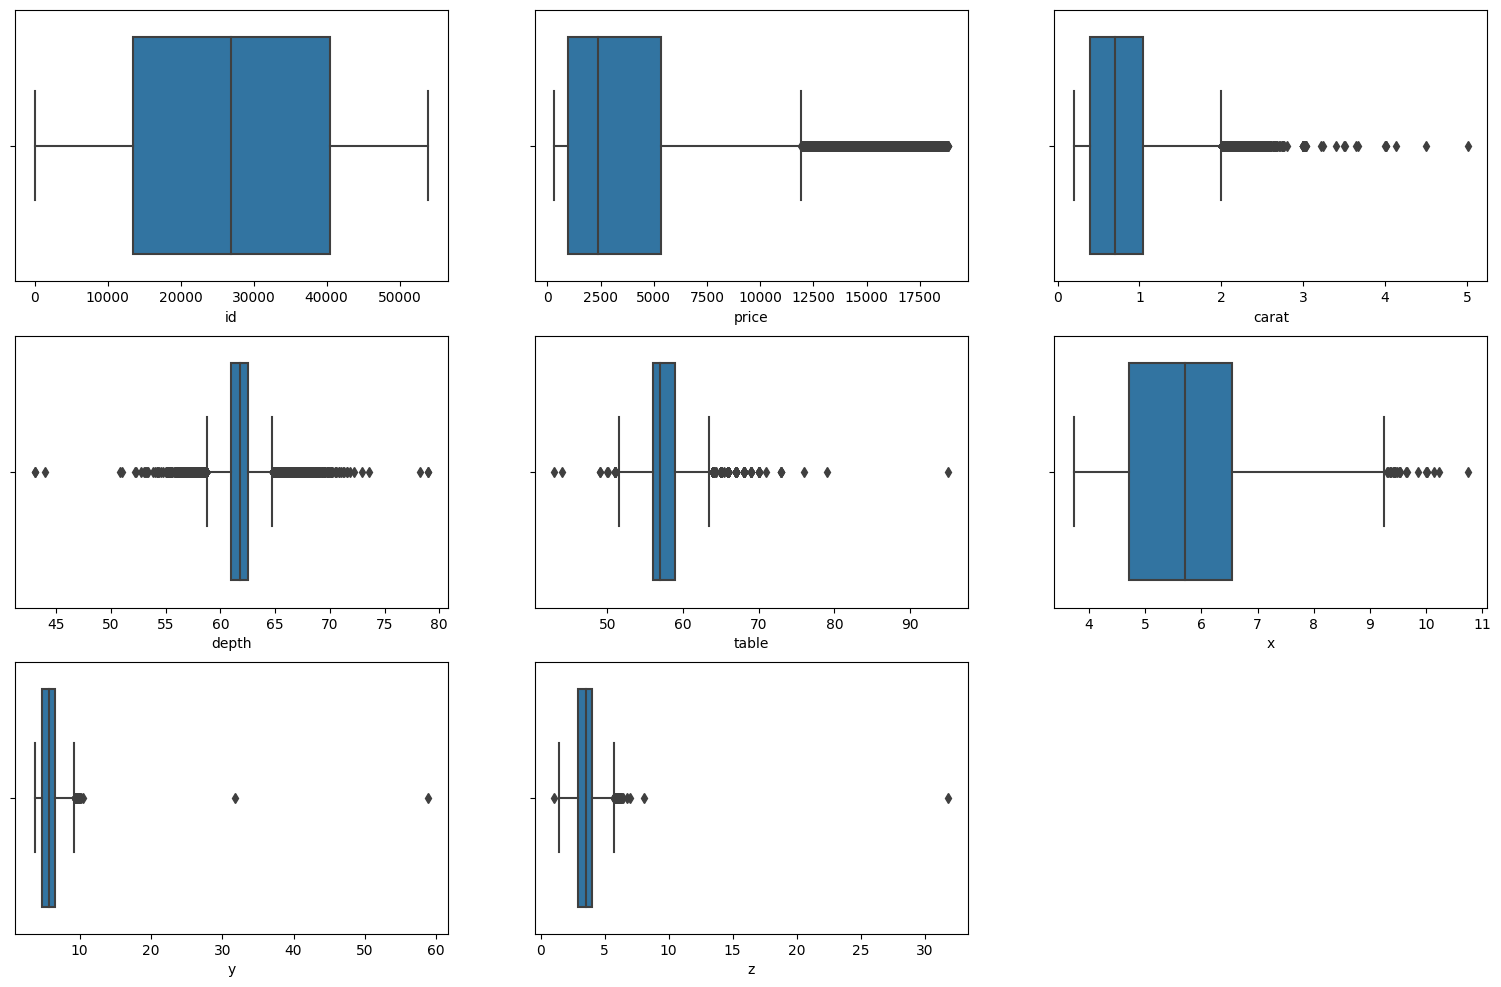

In [37]:

num_cols = train_data_clean.select_dtypes('number') # Selecting numeric features
pointer = 1                                #Initializes a variable to keep track of the current subplot index
plt.figure(figsize=(19, 12))
for i in num_cols.columns:
    plt.subplot(3, 3, pointer)
    sns.boxplot(x=train_data_clean[i])  # Creates a box plot for the current column "i" in the current subplot
    pointer+=1                          #Increments the variable to move to the next subplot

In [38]:
"""

 Selecting only the rows in "train_data_clean" where all numeric columns have
 z-scores within 3 standard deviations from the mean.
 
 Any row with at least one numeric value outside that threshold is removed from the DataFrame.
 
"""

from scipy import stats
num_cols = train_data_clean.select_dtypes('number')
train_data_clean = train_data_clean[(np.abs(stats.zscore(num_cols)) < 3).all(axis=1)]

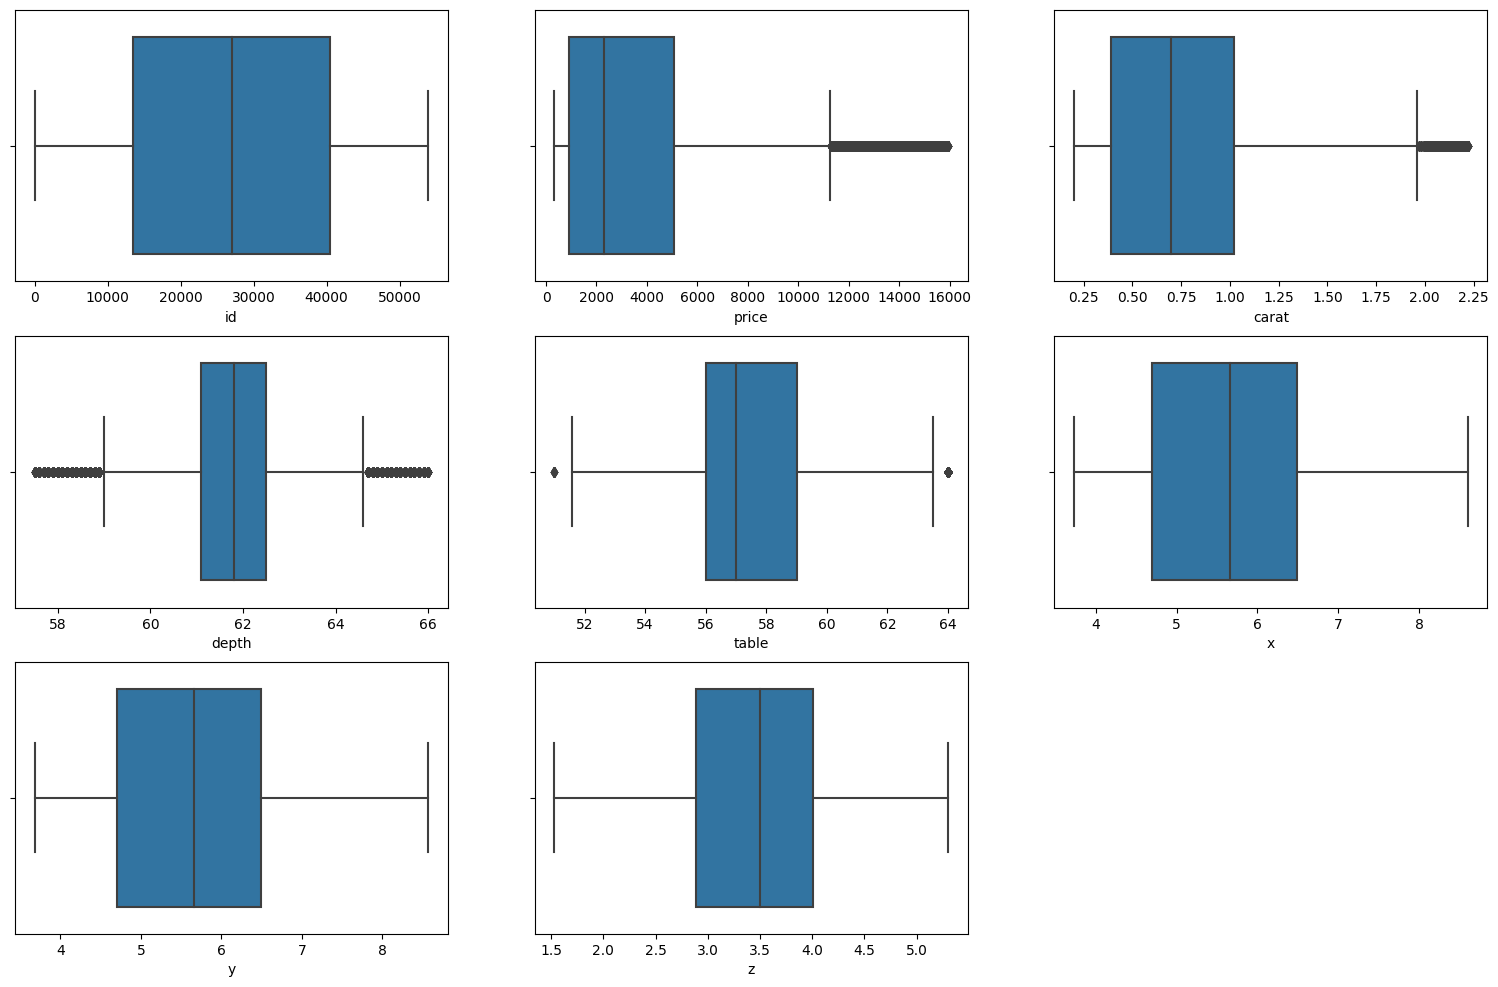

In [39]:
num_cols = train_data_clean.select_dtypes('number')
pointer = 1
plt.figure(figsize=(19, 12))
for i in num_cols.columns:
    plt.subplot(3, 3, pointer)
    sns.boxplot(x=train_data_clean[i])
    pointer+=1

# Data Visualization

**I.	Visualizing the Categorical variables distribution**

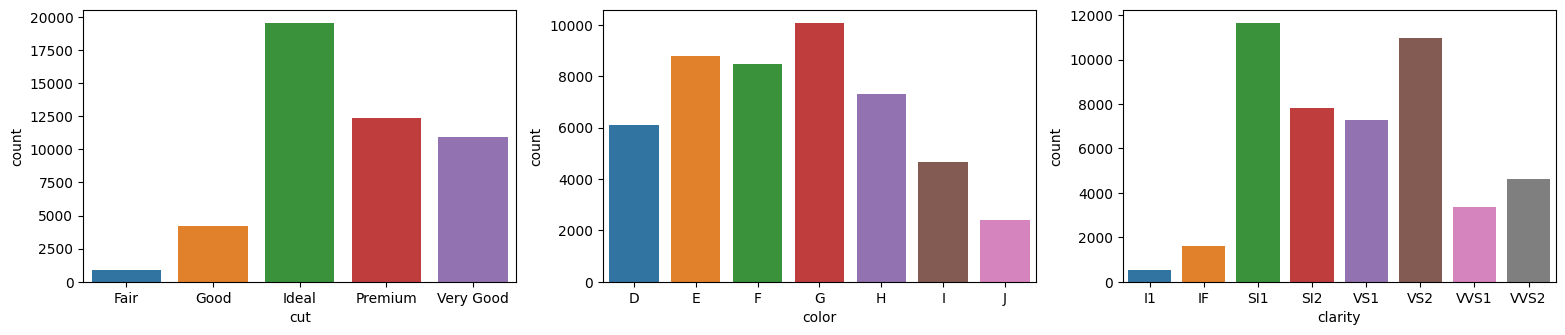

In [40]:
# Select all categorical features
cat_cols = train_data_clean.select_dtypes('O')

# Initialize subplot index
i = 1

# Create a figure with a size of 19 by 12 inches
plt.figure(figsize=(19, 12))

# Loop through each categorical feature and create a countplot
for c in cat_cols.columns:
    # Create a subplot
    plt.subplot(3, 3, i)
    
    # Create a countplot of the current categorical feature, sorted by value
    sns.countplot(x=train_data_clean[c].sort_values())
    
    # Increment the subplot index
    i += 1


**II.	Boxplots of Diamond Price by Cut, Color, and Clarity**

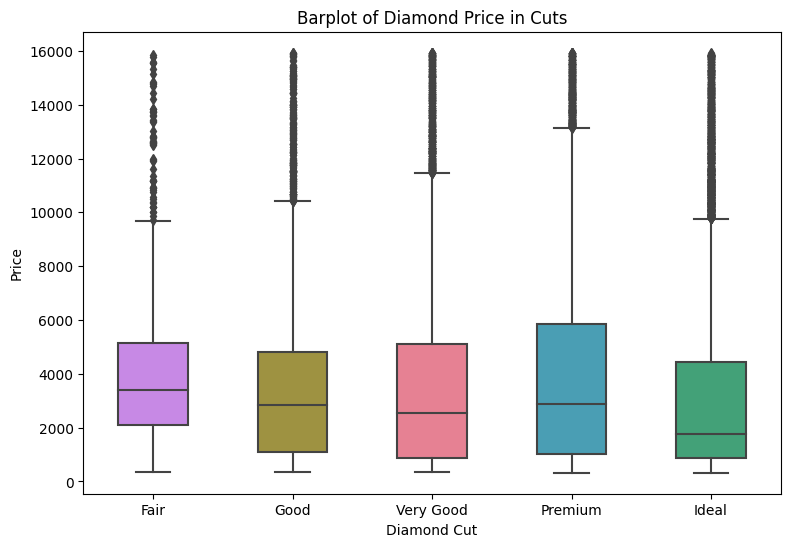

In [41]:
# Choose the size
cut_cats =  ['Fair','Good','Very Good','Premium','Ideal']
plt.figure(figsize=(9,6))
# Create plot
fig = sns.boxplot(y='price',x='cut',hue='cut',data=train_data_clean,palette='husl',order=cut_cats,width=0.5,
                  dodge=False)
fig.get_legend().remove()                      # Remove legend
plt.xlabel('Diamond Cut')                      # Horizontal labels
plt.ylabel('Price')                            # Vertical labels
plt.title('Barplot of Diamond Price in Cuts')  # Title of figure
plt.show(fig)

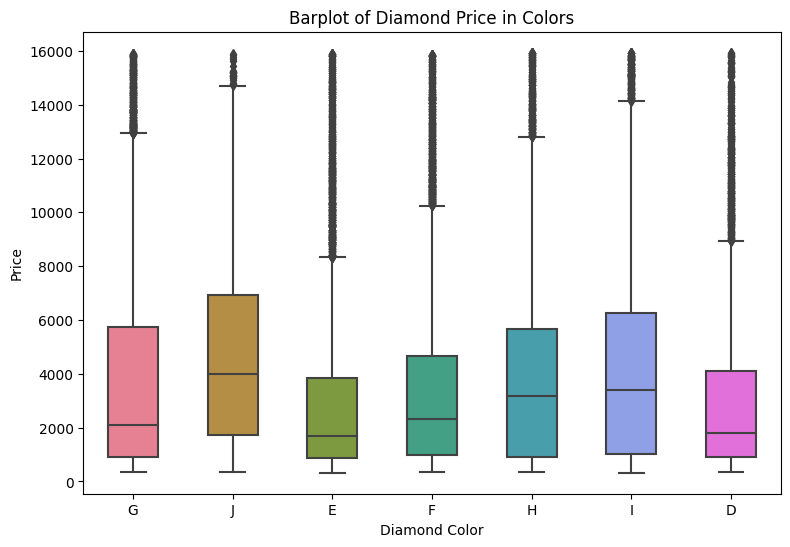

In [42]:
# Choose the size

plt.figure(figsize=(9,6))
# Create plot
fig = sns.boxplot(y='price',x='color',hue='color',data=train_data_clean,palette='husl',width=0.5,
                  dodge=False)
fig.get_legend().remove()                      # Remove legend
plt.xlabel('Diamond Color')                      # Horizontal labels
plt.ylabel('Price')                            # Vertical labels
plt.title('Barplot of Diamond Price in Colors')  # Title of figure
plt.show(fig)

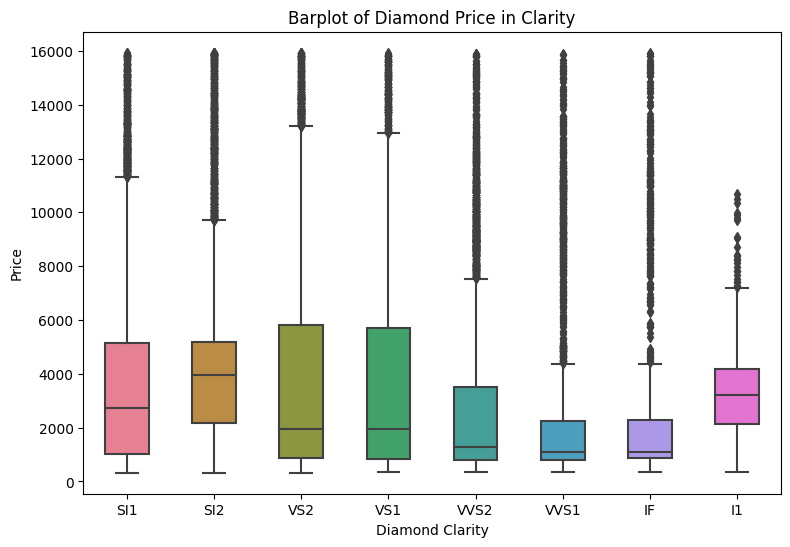

In [43]:
# Choose the size

plt.figure(figsize=(9,6))
# Create plot
fig = sns.boxplot(y='price',x='clarity',hue='clarity',data=train_data_clean,palette='husl',width=0.5,
                  dodge=False)
fig.get_legend().remove()                      # Remove legend
plt.xlabel('Diamond Clarity')                      # Horizontal labels
plt.ylabel('Price')                            # Vertical labels
plt.title('Barplot of Diamond Price in Clarity')  # Title of figure
plt.show(fig)

**III.	Scatter Plots of Price vs Various Diamond Features**

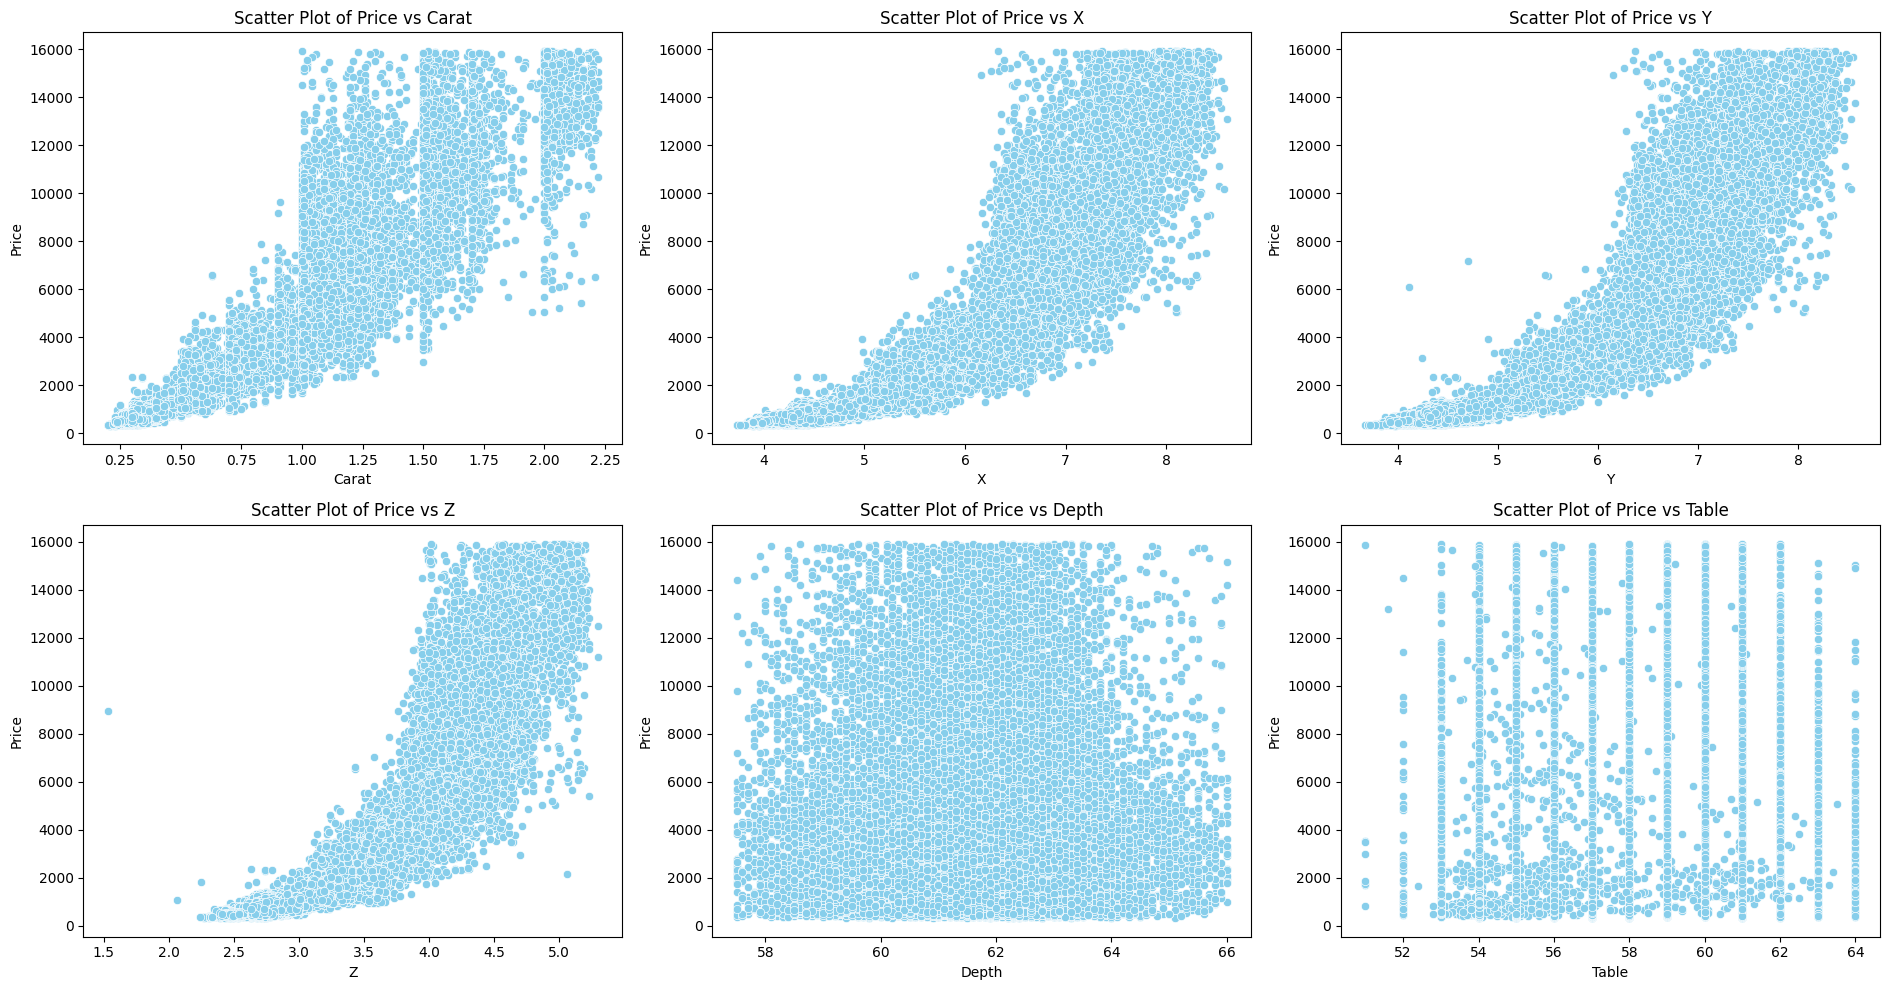

In [44]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a 2x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(19, 10))

# Loop over each subplot and corresponding feature, and plot a scatter plot
for ax, feature in zip(axes.flatten(), ['carat', 'x', 'y', 'z','depth', 'table']):
    sns.scatterplot(x=feature, y='price', data=train_data_clean, ax=ax,color='skyblue') # plot scatter plot
    ax.set_xlabel(feature.capitalize()) # set x-axis label with capitalized feature name
    ax.set_ylabel('Price') # set y-axis label
    ax.set_title(f'Scatter Plot of Price vs {feature.capitalize()}') # set title with capitalized feature name

# Adjust the spacing between subplots to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


# Statistic Test

**The ANOVA and Kruskal-Wallis tests were conducted on three categorical features ('color', 'cut', 'clarity') to investigate their effect on the numerical feature 'price'. For each feature, both tests were used to check if there is a significant difference in the mean or median price across the different categories. The results show that all three categorical features have a significant effect on the price of diamonds. Specifically, diamonds with higher color, cut, and clarity grades tend to have a higher price.**

In [45]:
import pandas as pd
from scipy.stats import f_oneway
from scipy.stats import kruskal

# Select the numerical feature and categorical features
num_col = 'price'
cat_cols = ['color', 'cut', 'clarity']

# Loop through each categorical feature and calculate ANOVA and Kruskal-Wallis tests
for cat_col in cat_cols:
    print(f"{'-'*50}\n{cat_col.upper()}:\n{'-'*50}")
    
    # Calculate ANOVA test
    groups = []
    for group in train_data_clean[cat_col].unique():
        groups.append(train_data_clean[train_data_clean[cat_col] == group][num_col])
    fvalue, pvalue = f_oneway(*groups)
    print(f"F-value: {fvalue:.2f}")
    print(f"p-value: {pvalue:.2e}")
    
    # Calculate Kruskal-Wallis test
    groups = []
    for group in train_data_clean[cat_col].unique():
        groups.append(train_data_clean[train_data_clean[cat_col] == group][num_col].values)
    hvalue, pvalue = kruskal(*groups)
    print(f"H-value: {hvalue:.2f}")
    print(f"p-value: {pvalue:.2e}")


--------------------------------------------------
COLOR:
--------------------------------------------------
F-value: 208.99
p-value: 3.06e-264
H-value: 933.59
p-value: 2.06e-198
--------------------------------------------------
CUT:
--------------------------------------------------
F-value: 146.86
p-value: 4.82e-125
H-value: 774.88
p-value: 2.12e-166
--------------------------------------------------
CLARITY:
--------------------------------------------------
F-value: 157.31
p-value: 8.01e-231
H-value: 2166.35
p-value: 0.00e+00


# Correlation Matrix

**id, table, depth does not show much correlation with price**

<AxesSubplot: >

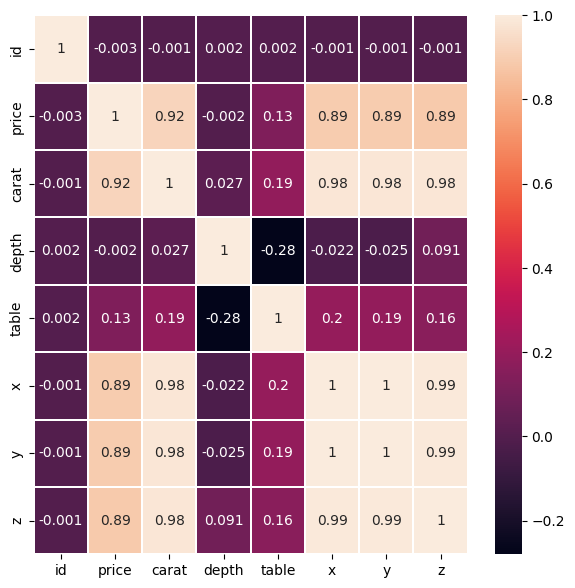

In [46]:
import seaborn as sns
corrmat = num_cols.corr() # For calculating correlation
f,ax = plt.subplots(figsize=(7,7))
sns.heatmap(round(corrmat,3),ax=ax,linewidths = 0.1,annot=True)

# Ordinal Encoding
**Encoding the ordinal variables**

**As per universal standards cut, color and clarity of diamond can been grouped into following category respectively**

**Fair --> Good --> Very Good --> Premium --> Ideal**

**J --> I --> H --> G --> F --> E --> D**

 **I1 --> SI2 --> SI1 --> VS2 --> VS1 --> VVS2 --> VVS1 --> IF**

In [47]:
# Mapping the categorical variables to numerical values for analysis
train_data_clean['cut'] = train_data_clean['cut'].map({'Fair':0, 'Good':1, 'Very Good':2, 'Premium':3, 'Ideal':4})
train_data_clean['color'] = train_data_clean['color'].map({'J':0, 'I':1, 'H':2, 'G':3, 'F':4, 'E':5, 'D':6})
train_data_clean['clarity'] = train_data_clean['clarity'].map({'I1':0, 'SI2':1, 'SI1':2, 'VS2':3, 'VS1':4, 'VVS2':5, 'VVS1':6, 'IF':7})

# Feature Selection and Target Setting

In [48]:
x = train_data_clean.drop(['price', 'table', 'depth','id'],axis=1)
y=train_data_clean['price']
x.values
y.values

array([ 2209,  2035,  2263, ...,   709,   682, 10349])

# Seperating training and testing data

In [49]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2,random_state=42)

# Linear Regression

In [50]:
from sklearn import linear_model
model = linear_model.LinearRegression()
# Fitting the model
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

from sklearn.metrics import mean_squared_error
from math import sqrt 
rms = sqrt(mean_squared_error(y_test, y_pred))

from sklearn.metrics import r2_score
#Calculating the accuracy
r2_score = model.score(x_test,y_test)
print(r2_score*100,'%')
from sklearn.metrics import mean_absolute_error
# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate mean absolute error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
# Load the actual prices from the test dataset
actual_prices = y_test.values

# Compare the predicted prices with the actual prices for 10 values
for i in range(10):
    print('Actual price: ${:.2f}, Predicted price: ${:.2f}'.format(actual_prices[i], y_pred[i]))


91.65528369299247 %
Mean Squared Error: 967366.1123280593
Mean Absolute Error: 683.8800285996642
Actual price: $489.00, Predicted price: $-605.17
Actual price: $478.00, Predicted price: $844.75
Actual price: $5871.00, Predicted price: $6230.16
Actual price: $3798.00, Predicted price: $4557.93
Actual price: $3082.00, Predicted price: $3663.14
Actual price: $596.00, Predicted price: $319.11
Actual price: $7255.00, Predicted price: $5971.26
Actual price: $2360.00, Predicted price: $3198.83
Actual price: $2368.00, Predicted price: $3176.89
Actual price: $14410.00, Predicted price: $13880.53


# XGBoost Regressor

In [51]:
from xgboost import XGBRegressor

my_model = XGBRegressor()

# Fitting the model
my_model.fit(x_train, y_train)
y_pred = my_model.predict(x_test)

#Calculating the accuracy
xb_score = my_model.score(x_test,y_test)
print(xb_score*100,'%')

# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate mean absolute error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

# Load the actual prices from the test dataset
actual_prices = y_test.values

# Compare the predicted prices with the actual prices for 10 values
for i in range(10):
    print('Actual price: ${:.2f}, Predicted price: ${:.2f}'.format(actual_prices[i], y_pred[i]))


98.37082123405223 %
Mean Squared Error: 188863.50010231617
Mean Absolute Error: 236.59904149862436
Actual price: $489.00, Predicted price: $498.83
Actual price: $478.00, Predicted price: $522.30
Actual price: $5871.00, Predicted price: $5783.73
Actual price: $3798.00, Predicted price: $4086.10
Actual price: $3082.00, Predicted price: $3397.33
Actual price: $596.00, Predicted price: $645.31
Actual price: $7255.00, Predicted price: $6591.39
Actual price: $2360.00, Predicted price: $2778.09
Actual price: $2368.00, Predicted price: $2781.61
Actual price: $14410.00, Predicted price: $14559.42


# Random Forest

In [52]:
from sklearn.ensemble import RandomForestRegressor

# n_estimators are the number of trees
model=RandomForestRegressor(n_estimators=10)

# Fitting the model
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

#Calculating the accuracy
rf_score = model.score(x_test,y_test)
print(rf_score*100,'%')

# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate mean absolute error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

# Load the actual prices from the test dataset
actual_prices = y_test.values

# Compare the predicted prices with the actual prices for 10 values
for i in range(10):
    print('Actual price: ${:.2f}, Predicted price: ${:.2f}'.format(actual_prices[i], y_pred[i]))

98.17739328122389 %
Mean Squared Error: 211286.7485219177
Mean Absolute Error: 243.24744741897592
Actual price: $489.00, Predicted price: $476.40
Actual price: $478.00, Predicted price: $488.00
Actual price: $5871.00, Predicted price: $5652.10
Actual price: $3798.00, Predicted price: $4002.30
Actual price: $3082.00, Predicted price: $3188.80
Actual price: $596.00, Predicted price: $626.10
Actual price: $7255.00, Predicted price: $6556.10
Actual price: $2360.00, Predicted price: $2826.40
Actual price: $2368.00, Predicted price: $2668.30
Actual price: $14410.00, Predicted price: $14820.90


# DecisionTree

In [53]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=1)

# Fitting the model
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

#Calculating the accuracy
dt_score = model.score(x_test,y_test)
print(dt_score*100,'%')
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# Calculate mean squared error
mse = mean_squared_error(y_test, y_pred)

# Calculate mean absolute error
mae = mean_absolute_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)

# Load the actual prices from the test dataset
actual_prices = y_test.values

# Compare the predicted prices with the actual prices for 10 values
for i in range(10):
    print('Actual price: ${:.2f}, Predicted price: ${:.2f}'.format(actual_prices[i], y_pred[i]))

96.95564281979759 %
Mean Squared Error: 352918.88442958007
Mean Absolute Error: 309.87935479375693
Actual price: $489.00, Predicted price: $489.00
Actual price: $478.00, Predicted price: $465.00
Actual price: $5871.00, Predicted price: $6058.00
Actual price: $3798.00, Predicted price: $4167.00
Actual price: $3082.00, Predicted price: $3175.00
Actual price: $596.00, Predicted price: $648.00
Actual price: $7255.00, Predicted price: $6660.00
Actual price: $2360.00, Predicted price: $2792.00
Actual price: $2368.00, Predicted price: $2723.00
Actual price: $14410.00, Predicted price: $15312.00


# Communication/Conclusion

**Then evaluated four machine learning models, including linear regression, decision tree, random forest, and XGBoost regressor. The XGBoost regressor was the most accurate model with 98.37% accuracy, followed by the random forest model with 98.20% accuracy. The decision tree model also performed well with an accuracy of 96.95% and linear regression giving 91.65% accuracy. 

The above findings demonstrate that machine learning models can effectively predict diamond prices based on their characteristics, and the XGBoost regressor and random forest models are well-suited for this task. These models can provide valuable insights into the factors that impact diamond prices and can be used to inform pricing decisions in the diamond industry.
**